In [5]:
import json
import os
import kagglehub
import importlib
import torch
import random
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
import pandas as pd
import numpy as np
import gc
from IPython.display import JSON
from torch.utils.data import Dataset
from tqdm import tqdm
from functools import partial
from src.jsonl_dataset import JsonLDataset
from transformers import AutoTokenizer, TrainingArguments, EvalPrediction
from adapters import AutoAdapterModel, AdapterTrainer

In [6]:
def clear_gpu_memory():
    gc.collect()
    torch.cuda.empty_cache()
    print(f"Allocated: {torch.cuda.memory_allocated() / 1024**2:.2f} MB")
    print(f"Reserved:  {torch.cuda.memory_reserved() / 1024**2:.2f} MB")

# Datasets Initialization

In [7]:
path = kagglehub.dataset_download("Cornell-University/arxiv/versions/272")
ds_path = os.path.join(path, 'arxiv-metadata-oai-snapshot.json')
master_ds = JsonLDataset(ds_path)
augmented_ds = JsonLDataset("resources/augmented_index.jsonl")

Indexing dataset at C:\Users\kerem\.cache\kagglehub\datasets\Cornell-University\arxiv\versions\272\arxiv-metadata-oai-snapshot.json... (this may take a minute)
Indexed 2951540 entries.
Indexing dataset at resources/augmented_index.jsonl... (this may take a minute)
Indexed 2951540 entries.


In [9]:
from src.utils import load_indices_from_jsonl

In [10]:
train_indices = load_indices_from_jsonl("resources/train_indicies_parent_categories.jsonl", flatten=True, shuffle=True, seed=42)
test_indices = load_indices_from_jsonl("resources/test_indices_parent_categories.jsonl", flatten=True, shuffle=True, seed=42)

In [12]:
class IndexBasedDataset(Dataset):
    """
    The indices in the dataset are engineered based on the specific task. 
    They are precomputed, and stored in the /resources folder.
    The indices ensure the classes distribution match the training task requirements.
    For details on how the indices are constructed - check data_selection.ipynb
    """
    
    def __init__(self, master_dataset, augmented_datset, indices):
        self.master_dataset = master_dataset
        self.augmented_datset = augmented_datset
        self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        master_idx = self.indices[idx]
        return {
            "master_idx": master_idx,
            "title": self.master_dataset[master_idx]["title"],
            "abstract": self.master_dataset[master_idx]["abstract"],
            "raw_categories": self.master_dataset[master_idx]["categories"],
            "parent_categories": self.augmented_datset[master_idx][2],
            "remapped_categories": self.augmented_datset[master_idx][3]
        }

In [13]:
pipeline_test = False
if pipeline_test:
    sub_train_size = 1000
    sub_test_size = 200
    train_ds = IndexBasedDataset(master_ds, augmented_ds, np.random.choice(train_indices, sub_train_size))
    test_ds = IndexBasedDataset(master_ds, augmented_ds, np.random.choice(train_indices, sub_test_size))
else:
    train_ds = IndexBasedDataset(master_ds, augmented_ds, train_indices)
    test_ds = IndexBasedDataset(master_ds, augmented_ds, test_indices)

# Train Pipeline

In [8]:
class Collator:
    def __init__(self, tokenizer, mlb, is_parent=False):
        self.tokenizer = tokenizer
        self.mlb = mlb
        self.is_parent = is_parent

    def __call__(self, batch):
        texts = [
            f"{item['title']}{self.tokenizer.sep_token}{item.get('abstract', '')}" 
            for item in batch
        ]

        inputs = self.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        if self.is_parent:
            raw_labels = [item['parent_categories'] for item in batch]
        else:
            raw_labels = [item['raw_categories'].split() for item in batch]
        
        # Transform [['Physics'], ['Math', 'CS']] -> [[1,0...], [0,1,1...]]
        # Note: We must convert to FloatTensor for BCEWithLogitsLoss (Multi-label loss)
        labels_encoded = self.mlb.transform(raw_labels)
        inputs['labels'] = torch.tensor(labels_encoded, dtype=torch.float32)

        return inputs

In [9]:
import torch
import gc
from dataclasses import dataclass
from transformers import AutoTokenizer, TrainingArguments, EvalPrediction
from adapters import AutoAdapterModel, AdapterTrainer, Stack  # <--- Imported Stack
from sklearn.metrics import f1_score

@dataclass
class TrainingConfig:
    learning_rate: float = 1e-4
    num_train_epochs: int = 3
    train_batch_size: int = 8
    eval_batch_size: int = 8
    logging_steps: int = 50
    save_strategy: str = "epoch"
    eval_strategy: str = "epoch"

def train_pipeline(
    train_dataset, 
    eval_dataset=None, 
    hyperparams: TrainingConfig = TrainingConfig(),
    output_dir: str = "./checkpoints",
    adapter_save_path: str = "./final_multilabel_adapter",
    device: str = "cuda",
    adapter_name: str = None,
    num_target_classes: int = -1,
    mlb = None,
    is_parent: bool = False
):
    print(f"Using device: {device}")

    # --- B. Load Model ---
    model_name = "allenai/specter2_base"
    model = AutoAdapterModel.from_pretrained(model_name)
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model.to(device) # Move to GPU explicitly
    
    # 1. Load (frozen base)
    model.load_adapter("allenai/specter2_classification", source="hf", load_as=adapter_name)

    # 2. Add Head
    model.add_classification_head(
        adapter_name,
        num_labels=num_target_classes,
        multilabel=True  
    )
    
    # 3. Activation (The Fix)
    model.train_adapter(adapter_name)           # Enable gradients
    model.set_active_adapters(adapter_name)
    model.active_head = adapter_name            # Force prediction head

    # --- D. Metrics ---
    def compute_metrics(p: EvalPrediction):
        probs = torch.sigmoid(torch.tensor(p.predictions)).numpy()
        preds = (probs > 0.5).astype(int)
        labels = p.label_ids
        return {
            "f1_micro": f1_score(labels, preds, average="micro"),
            "f1_macro": f1_score(labels, preds, average="macro"),
        }

    # --- E. Trainer ---
    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=hyperparams.learning_rate,
        num_train_epochs=hyperparams.num_train_epochs,
        per_device_train_batch_size=hyperparams.train_batch_size,
        per_device_eval_batch_size=hyperparams.eval_batch_size,
        logging_steps=hyperparams.logging_steps,
        eval_strategy=hyperparams.eval_strategy if eval_dataset else "no",
        save_strategy=hyperparams.save_strategy,
        remove_unused_columns=False,
        report_to="none"
    )

    trainer = AdapterTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,
        data_collator=Collator(tokenizer, mlb, is_parent), 
        compute_metrics=compute_metrics,
    )

    # --- Safety Wrapper ---
    try:
        print("🚀 Starting training...")
        trainer.train()
        
        print(f"✅ Training complete. Saving to {adapter_save_path}...")
        model.save_adapter(adapter_save_path, adapter_name)
        return model

    except KeyboardInterrupt:
        print("\n🛑 Interrupted!")
        del trainer, training_args
        gc.collect()
        torch.cuda.empty_cache()
        raise

    except Exception as e:
        del trainer
        gc.collect()
        torch.cuda.empty_cache()
        raise e

## Parent category training

In [10]:
from sklearn.preprocessing import MultiLabelBinarizer

# 1. Define your Fixed Taxonomy
TARGET_PARENT_CLASSES = [
    'Physics', 
    'Mathematics', 
    'Computer Science', 
    'Quantitative Biology', 
    'Statistics', 
    'Quantitative Finance', 
    'Economics', 
    'Electrical Engineering and Systems Science'
]

def create_mlb(target_classes):
    mlb = MultiLabelBinarizer(classes=target_classes)
    mlb.fit([target_classes])
    return mlb

mlb_parent = create_mlb(TARGET_PARENT_CLASSES)

### Adapter 1

In [11]:
config = TrainingConfig(
    learning_rate=5e-4,
    num_train_epochs=3,
    train_batch_size=20,
    logging_steps=10
)

trained_model = train_pipeline(
    train_dataset=train_ds, 
    eval_dataset=test_ds, 
    hyperparams=config,
    output_dir="./checkpoints",
    adapter_save_path="./resources/parent_categories_adapter",
    adapter_name="arxiv_parent_categories_classifier",
    num_target_classes=len(TARGET_PARENT_CLASSES),
    mlb=mlb_parent,
    is_parent=True
)

Using device: cuda


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


🚀 Starting training...


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.168900,0.175614,0.827542,0.825965
2,0.144400,0.165705,0.838012,0.836284
3,0.160200,0.162893,0.840713,0.839562


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning: unknown class(es) ['Other/Legacy'] will be ignored
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning: unknown class(es) ['Other/Legacy'] will be ignored
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning: unknown class(es) ['Other/Legacy'] will be ignored
  warnings.warn(


✅ Training complete. Saving to ./resources/parent_categories_adapter...


### Adapter 2

In [11]:
train_indices_bucket2 = load_indices_from_jsonl("resources/train_indicies_parent_categories_b2.jsonl", flatten=True, shuffle=True, seed=42)
train_ds_bucket2 = IndexBasedDataset(master_ds, augmented_ds, train_indices_bucket2)

In [12]:
### Second adapter training on the second data bucket.
config = TrainingConfig(
    learning_rate=5e-4,
    num_train_epochs=1,
    train_batch_size=20,
    logging_steps=10
)

trained_model = train_pipeline(
    train_dataset=train_ds_bucket2, 
    eval_dataset=test_ds, 
    hyperparams=config,
    output_dir="./checkpoints",
    adapter_save_path="./resources/parent_categories_adapter_bucket2",
    adapter_name="arxiv_parent_categories_classifier_bucket2",
    num_target_classes=len(TARGET_PARENT_CLASSES),
    mlb=mlb_parent,
    is_parent=True
)

Using device: cuda


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


🚀 Starting training...


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.176600,0.169727,0.832456,0.831009


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning: unknown class(es) ['Other/Legacy'] will be ignored
  warnings.warn(


✅ Training complete. Saving to ./resources/parent_categories_adapter_bucket2...


### Adapter 3

In [15]:
train_indices_bucket3 = load_indices_from_jsonl("resources/train_indicies_parent_categories_b3.jsonl", flatten=True, shuffle=True, seed=42)
train_ds_bucket3 = IndexBasedDataset(master_ds, augmented_ds, train_indices_bucket3)

In [17]:
### Third adapter training on the third data bucket.
config = TrainingConfig(
    learning_rate=5e-4,
    num_train_epochs=1,
    train_batch_size=20,
    logging_steps=10
)

trained_model = train_pipeline(
    train_dataset=train_ds_bucket3, 
    eval_dataset=test_ds, 
    hyperparams=config,
    output_dir="./checkpoints",
    adapter_save_path="./resources/parent_categories_adapter_bucket3",
    adapter_name="arxiv_parent_categories_classifier_bucket3",
    num_target_classes=len(TARGET_PARENT_CLASSES),
    mlb=mlb_parent,
    is_parent=True
)

Using device: cuda


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


🚀 Starting training...


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.150400,0.169491,0.833190,0.832021


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:900: UserWarning: unknown class(es) ['Other/Legacy'] will be ignored
  warnings.warn(


✅ Training complete. Saving to ./resources/parent_categories_adapter_bucket3...


In [83]:
clear_gpu_memory()

Allocated: 4332.46 MB
Reserved:  4514.00 MB


## Sub category training

In [11]:
TARGET_SUB_CLASSES = json.load(open("resources/target_sub_classes.json", "r"))

In [12]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

In [13]:
pipeline_test = False

subc_config = TrainingConfig(
    learning_rate=5e-4,
    num_train_epochs=2,
    train_batch_size=20,
)

for parent_category, sub_categories in TARGET_SUB_CLASSES.items():
    print(f"Training classifier for category: {parent_category.upper()}")
    
    train_subc_ind = load_indices_from_jsonl(f"resources/train_indicies_{parent_category}_categories.jsonl", flatten=True, shuffle=True, seed=42)
    test_subc_ind = load_indices_from_jsonl(f"resources/test_indices_{parent_category}_categories.jsonl", flatten=True, shuffle=True, seed=42)


    if pipeline_test:
        sub_train_size = 100
        sub_test_size = 20
        train_subc_ds = IndexBasedDataset(master_ds, augmented_ds, np.random.choice(train_subc_ind, sub_train_size))
        test_subc_ds = IndexBasedDataset(master_ds, augmented_ds, np.random.choice(test_subc_ind, sub_test_size))
    else:
        train_subc_ds = IndexBasedDataset(master_ds, augmented_ds, train_subc_ind)
        test_subc_ds = IndexBasedDataset(master_ds, augmented_ds, test_subc_ind)
    
    print(f"Train size: {len(train_subc_ds)}. Test size: {len(test_subc_ds)}. Total classes: {len(sub_categories)}")
    print("-" * 50)

    mlb = create_mlb(sub_categories)
    
    train_pipeline(
        train_dataset=train_subc_ds, 
        eval_dataset=test_subc_ds, 
        hyperparams=subc_config,
        output_dir="./checkpoints",
        adapter_save_path=f"./resources/{parent_category}_categories_adapter",
        adapter_name=f"arxiv_{parent_category}_categories_classifier",
        num_target_classes=len(sub_categories),
        mlb=mlb,
        is_parent=False
    )

    print(f"\n\n{"-" * 100}\n\n")


Training classifier for category: PHYSICS
Train size: 52138. Test size: 10581. Total classes: 53
--------------------------------------------------
Using device: cuda


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


🚀 Starting training...


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.069800,0.065957,0.612225,0.583310
2,0.058300,0.062741,0.628857,0.604968


...

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

There are adapters available but none are activated for the forward pass.


🚀 Starting training...


Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.160600,0.158233,0.887839,0.889251
2,0.111900,0.140520,0.897497,0.898265


✅ Training complete. Saving to ./resources/Electrical Engineering and Systems Science_categories_adapter...


----------------------------------------------------------------------------------------------------




In [1]:
avg_f1 = 0.897 + 0.826 + 0.584 + 0.637 + 0.6411 + 0.656 + 0.645 + 0.628

In [2]:
avg_f1 / 8

0.6892624999999999

In [65]:
len(train_subc_ds)

5921

## Validation

In [32]:
def classify_sample(
    model, 
    tokenizer, 
    text_input: str, 
    target_classes: list, 
    device: str = "cuda", 
    threshold: float = 0.5
):
    """
    Classifies a single text sample using the loaded Adapter model.
    """
    # 1. Prepare Model
    model.eval()  # Disable dropout/batchnorm for inference
    model.to(device)
    
    # 2. Tokenize
    # Specter 2 handles inputs up to 512 tokens. 
    # If passing Title + Abstract, ensure they are concatenated properly before this.
    inputs = tokenizer(
        text_input,
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    )
    
    # Move inputs to the same device as the model
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # 3. Inference
    with torch.no_grad():
        outputs = model(**inputs)
    
    # 4. Process Logits
    # The model output depends on the head configuration. 
    # For AutoAdapterModel with a head, outputs.logits contains the classification scores.
    logits = outputs.logits
    
    # Apply Sigmoid because we defined multilabel=True (independent probabilities)
    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
    
    # 5. Decode to Labels
    # Get indices where probability is higher than threshold
    predicted_indices = (probs > threshold).nonzero()[0]
    
    # Map indices to class names
    predicted_labels = [target_classes[i] for i in predicted_indices]
    
    # Create a detailed result with confidence scores
    results = [
        {"label": target_classes[i], "score": float(probs[i])} 
        for i in predicted_indices
    ]
    
    # Sort by confidence (highest first)
    results.sort(key=lambda x: x["score"], reverse=True)
    
    return results

In [14]:
tokenizer = AutoTokenizer.from_pretrained("allenai/specter2_base")

In [49]:
rand_idx = random.randint(0, len(test_ds))

sample = test_ds[rand_idx]
inp = f"{sample['title']}{tokenizer.sep_token}{sample.get('abstract', '')}"

print(classify_sample(trained_model, tokenizer, inp, TARGET_PARENT_CLASSES))
JSON(sample)

[{'label': 'Quantitative Finance', 'score': 0.9878662824630737}]


<IPython.core.display.JSON object>

# Check how often the NR of tokens generated by the tokenizer exceed the 512 threshold

<b>We have 241 abstracts that have more than 512 tokens after tokenized, out of 77338 samples.</b></br>
This ratio is neglectable and I won't introduce any fancy logic to handle those cases.

In [36]:
num_tokens = []
for sample in tqdm(train_ds):
    inputs = tokenizer(
        f"{sample['title']}{tokenizer.sep_token}{sample.get('abstract', '')}",
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding="max_length"
    )
    
    num_tokens.append(inputs["attention_mask"].sum().item())

100%|█████████████████████████████████████████████████████████████████████████████████████| 77338/77338 [04:27<00:00, 289.02it/s]


In [17]:
def plot_histogram(data, bins=10, title="Histogram of the tokencount in the abstract", xlabel="Values", color='skyblue'):
    plt.figure(figsize=(10, 6))  # Set figure size
    
    # Plot the histogram
    # edgecolor='black' adds a border to each bar for better visibility
    plt.hist(data, bins=bins, color=color, edgecolor='black', alpha=0.7)
    
    # Add labels and title
    plt.title(title + f" of {len(data)} samples.")
    plt.xlabel(xlabel)
    plt.ylabel("Frequency")
    
    # Add a grid behind the bars
    plt.grid(axis='y', alpha=0.5)
    
    # Display the plot
    plt.show()

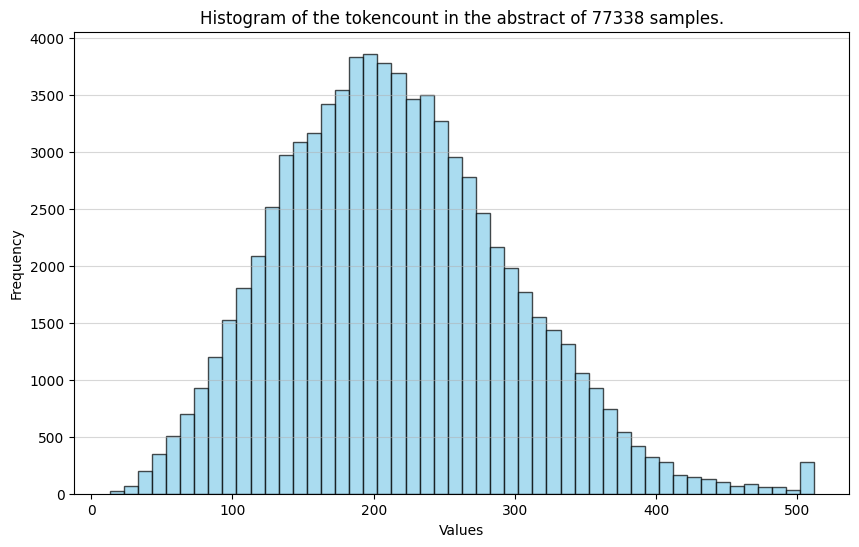

In [38]:
plot_histogram(num_tokens, bins=50)

In [39]:
np.array(np.array(num_tokens) == 512).sum()

241

In [40]:
len(train_ds)

77338

In [61]:
model.active_adapters.first()

'arxiv_parent_categories_classifier'

In [69]:
import warnings

# This tells Python: "If you see this specific warning message, crash immediately."
warnings.filterwarnings("error", message="There are adapters available but none are activated for the forward pass.")

In [81]:
active_adapters = getattr(model, "active_adapters", None)
if not active_adapters:
    if model.has_adapters():
        logger.warning("There are adapters available but none are activated for the forward pass.")
else:
    print("Hui")

Hui


In [79]:
active_adapters

Stack[arxiv_parent_categories_classifier]

In [72]:
model.active_adapters

Stack[arxiv_parent_categories_classifier]

In [71]:
model.has_adapters()

True

# [UNK] token count after tokenization

In [15]:
unk_counts = []
unk_token_id = tokenizer.unk_token_id

for sample in tqdm(train_ds):
    inputs = tokenizer(
        f"{sample['title']}{tokenizer.sep_token}{sample.get('abstract', '')}",
        return_tensors="pt",
        truncation=True,
        max_length=512,
        padding=False
    )
    
    # Count occurrences of the [UNK] ID in the input_ids tensor
    num_unks = (inputs["input_ids"] == unk_token_id).sum().item()
    unk_counts.append(num_unks)

100%|███████████████████████████████████████████████████████████████████████████| 77338/77338 [04:19<00:00, 297.79it/s]


In [20]:
np.unique(unk_counts)

array([0])

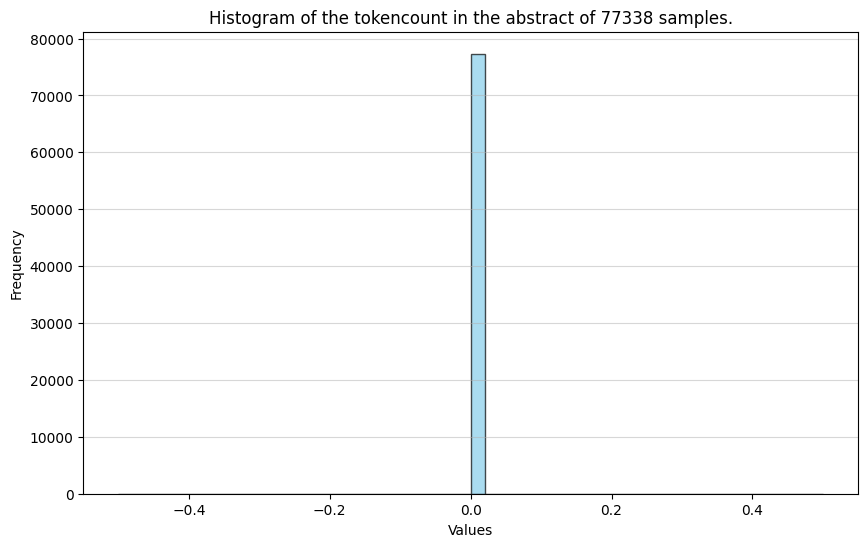

In [18]:
plot_histogram(unk_counts, bins=50)

# Fertility rate of the tokenizer

In [21]:
results = []

for sample in tqdm(train_ds):
    text = f"{sample['title']} {sample.get('abstract', '')}"
    
    # 1. Count raw words
    word_count = len(text.split())
    if word_count == 0: continue # Avoid division by zero
    
    # 2. Count tokens (excluding padding/special tokens for accuracy)
    encoded = tokenizer.encode(text, add_special_tokens=False)
    token_count = len(encoded)
    
    # 3. Calculate Ratio
    fertility = token_count / word_count
    
    results.append({
        "fertility": fertility,
        "tokens": token_count,
        "words": word_count
    })

# Get the average across the dataset
avg_fertility = sum(r['fertility'] for r in results) / len(results)
print(f"Average Fertility Rate: {avg_fertility:.2f}")

100%|███████████████████████████████████████████████████████████████████████████| 77338/77338 [03:13<00:00, 400.25it/s]

Average Fertility Rate: 1.31
